In [18]:
import numpy as np
print(np.__version__)

2.4.6


In [19]:
import pvlib
import numpy as np
import matplotlib.pyplot as plt

spectra = pvlib.spectrum.get_reference_spectra()
spectra.head()





,extraterrestrial,global,direct
wavelength,,,
280.0,0.082,4.730900e-23,2.536100e-26
280.5,0.099,1.230700e-21,1.091700e-24
281.0,0.150,5.689500e-21,6.125300e-24
281.5,0.212,1.566200e-19,2.747900e-22
282.0,0.267,1.194600e-18,2.834600e-21


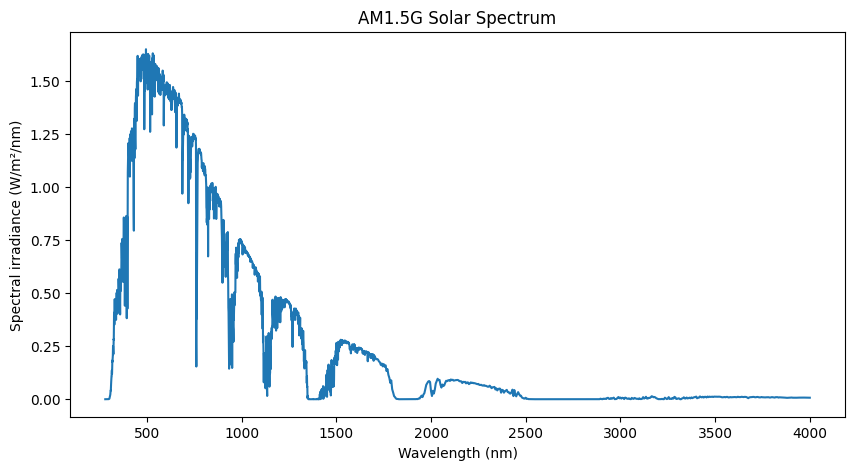

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(spectra.index, spectra['global'])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral irradiance (W/m²/nm)')
plt.title('AM1.5G Solar Spectrum')
plt.show()

In [21]:
total_power = np.trapezoid(spectra['global'], spectra.index)
print(total_power)

1000.3706555734423


In [22]:
h = 6.626e-34      # Planck's constant, J·s
c = 3.0e8          # speed of light, m/s

wavelength_m = spectra.index.values * 1e-9   # nm → meters

photon_energy = h * c / wavelength_m         # E = hc/λ, in Joules

print(photon_energy[:5])

[7.09928571e-19 7.08663102e-19 7.07402135e-19 7.06145648e-19
 7.04893617e-19]


In [23]:
photon_flux = spectra['global'].values / photon_energy
print(photon_flux[:5])

[6.66390985e-05 1.73665032e-03 8.04280863e-03 2.21795603e-01
 1.69472382e+00]


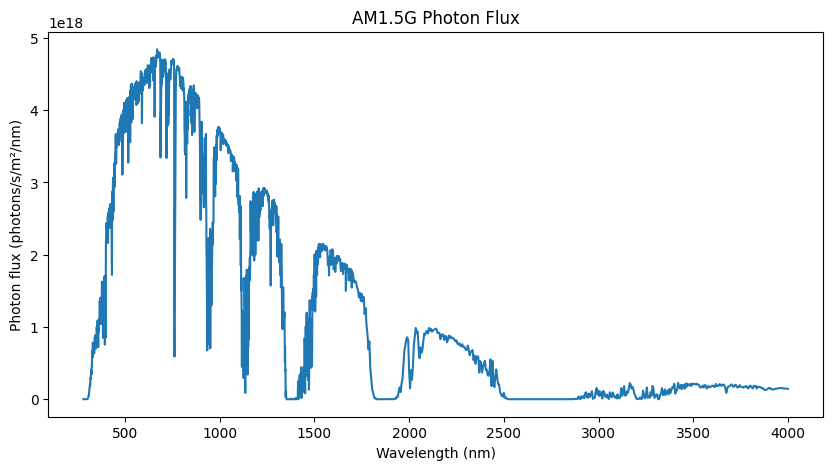

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(spectra.index, photon_flux)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Photon flux (photons/s/m²/nm)')
plt.title('AM1.5G Photon Flux')
plt.show()

In [25]:
Eg_eV = 1.34                          # chosen bandgap, electron-volts
q = 1.602e-19                         # electron charge, Coulombs

Eg_J = Eg_eV * q                      # bandgap in Joules
cutoff_wavelength_nm = (h * c / Eg_J) * 1e9    # λ = hc/E, then m → nm

print(f"Cutoff wavelength: {cutoff_wavelength_nm:.1f} nm")

Cutoff wavelength: 926.0 nm


In [26]:
# Keep only wavelengths shorter than the cutoff (these get absorbed)
absorbed = spectra.index.values < cutoff_wavelength_nm

wl_absorbed = spectra.index.values[absorbed]      # wavelengths below cutoff
flux_absorbed = photon_flux[absorbed]             # photon flux at those wavelengths

# Integrate photon flux over absorbed wavelengths = electrons per second per m²
electron_flux = np.trapezoid(flux_absorbed, wl_absorbed)

# Convert electron count to current: multiply by electron charge
J_sc = electron_flux * q                           # Amps per m²

print(f"J_sc = {J_sc:.2f} A/m²")
print(f"J_sc = {J_sc/10:.2f} mA/cm²")              # the unit PV people actually use

J_sc = 349.91 A/m²
J_sc = 34.99 mA/cm²


In [27]:
print(J_sc, photon_energy[:3])

349.9111608158428 [7.09928571e-19 7.08663102e-19 7.07402135e-19]


In [28]:
k_B = 1.381e-23      # Boltzmann's constant, J/K
T = 300              # cell temperature, K

In [29]:
exponent = photon_energy / (k_B * T)       # this is E/(k_B·T), the ratio you computed by hand
bose_factor = 1 / (np.exp(exponent) - 1)   # 1/(e^ratio − 1), the emission shape

print("First exponent value:", exponent[0])
print("Bose factor at first wavelength:", bose_factor[0])

First exponent value: 171.35616013240923
Bose factor at first wavelength: 3.8103530243054166e-75


In [30]:
# --- J_0: baseline thermal emission (the "leak") ---
# Three ingredients: prefactor (slots) × bose factor (fullness), above-bandgap only

wl_m = spectra.index.values * 1e-9              # wavelength in meters (SI for the prefactor)
exponent = photon_energy / (k_B * T)            # E/(k_B·T) — the ratio
bose_factor = 1 / (np.exp(exponent) - 1)        # photons per mode (fullness)
prefactor = (2 * np.pi * c) / (wl_m**4)         # available modes per wavelength (slots)

emission_spectrum = prefactor * bose_factor     # slots × fullness = total emission

# Reciprocity: cell emits only where it absorbs -> above-bandgap (below cutoff) only
absorbed = spectra.index.values < cutoff_wavelength_nm

emitted_photon_flux = np.trapezoid(emission_spectrum[absorbed], wl_m[absorbed])
J_0 = emitted_photon_flux * q                   # convert to current

print(f"J_0 = {J_0:.3e} A/m²")


J_0 = 2.273e-16 A/m²


In [31]:
V_oc = (k_B * T / q) * np.log(J_sc / J_0 + 1)
print(f"V_oc = {V_oc:.4f} V")

V_oc = 1.0830 V


In [32]:
print(f"J_sc = {J_sc:.2f} A/m²")
print(f"J_0  = {J_0:.3e} A/m²")
print(f"V_oc = {V_oc:.4f} V")

J_sc = 349.91 A/m²
J_0  = 2.273e-16 A/m²
V_oc = 1.0830 V


In [33]:
# Fill factor: fraction of the J_sc × V_oc rectangle actually captured at max-power point
# Standard empirical formula (depends on a normalized voltage)
v = V_oc * q / (k_B * T)                          # normalized voltage (dimensionless)
FF = (v - np.log(v + 0.72)) / (v + 1)             # empirical ideal fill factor

print(f"Normalized voltage v = {v:.2f}")
print(f"Fill factor FF = {FF:.4f}")

Normalized voltage v = 41.88
Fill factor FF = 0.8892


In [34]:
P_in = np.trapezoid(spectra['global'], spectra.index.values)   # incoming sunlight power, ~1000 W/m²

P_out = J_sc * V_oc * FF        # electrical power out = current × voltage × fill factor

efficiency = P_out / P_in

print(f"P_in  = {P_in:.2f} W/m²")
print(f"P_out = {P_out:.2f} W/m²")
print(f"Efficiency = {efficiency*100:.2f} %")

P_in  = 1000.37 W/m²
P_out = 336.96 W/m²
Efficiency = 33.68 %


In [35]:
def efficiency_for_bandgap(Eg_eV):
    # --- everything that depends on the bandgap, in order ---
    Eg_J = Eg_eV * q
    cutoff_nm = (h * c / Eg_J) * 1e9

    # photons absorbed (below cutoff) -> J_sc
    absorbed = spectra.index.values < cutoff_nm
    electron_flux = np.trapezoid(photon_flux[absorbed], spectra.index.values[absorbed])
    J_sc = electron_flux * q

    # thermal emission (above bandgap only) -> J_0
    emitted = np.trapezoid(emission_spectrum[absorbed], wl_m[absorbed])
    J_0 = emitted * q

    # voltage
    V_oc = (k_B * T / q) * np.log(J_sc / J_0 + 1)

    # fill factor
    v = V_oc * q / (k_B * T)
    FF = (v - np.log(v + 0.72)) / (v + 1)

    # efficiency
    P_out = J_sc * V_oc * FF
    efficiency = P_out / P_in
    return efficiency

In [36]:
print(efficiency_for_bandgap(1.34) * 100)

33.68393766589242


In [37]:
bandgaps = np.linspace(0.5, 3.0, 100)   # 100 bandgap values from 0.5 to 3.0 eV
print(bandgaps[:5], "...", bandgaps[-1])

[0.5        0.52525253 0.55050505 0.57575758 0.6010101 ] ... 3.0


In [38]:
efficiencies = [efficiency_for_bandgap(Eg) * 100 for Eg in bandgaps]


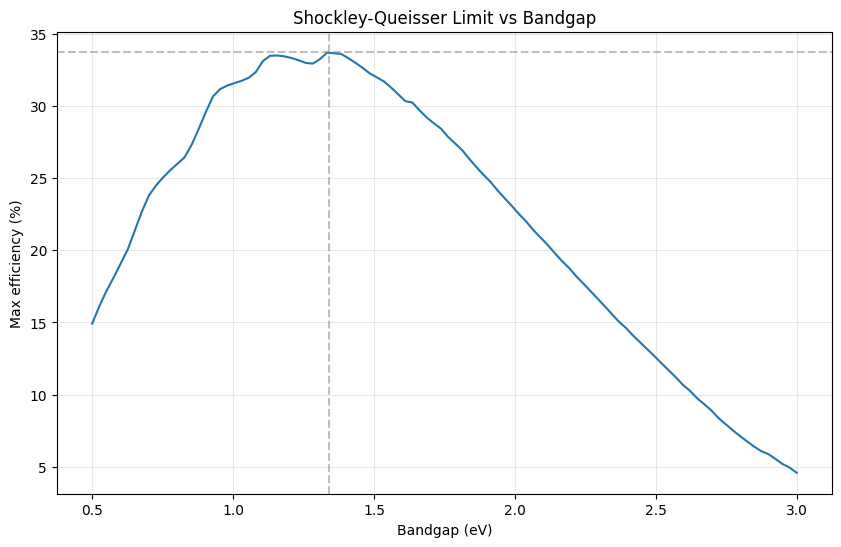

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(bandgaps, efficiencies)
plt.xlabel('Bandgap (eV)')
plt.ylabel('Max efficiency (%)')
plt.title('Shockley-Queisser Limit vs Bandgap')
plt.axhline(33.7, color='gray', linestyle='--', alpha=0.5)   # mark the ~33.7% line
plt.axvline(1.34, color='gray', linestyle='--', alpha=0.5)   # mark the 1.34 eV line
plt.grid(True, alpha=0.3)
plt.show()